# Fourier-space based turbulent field generation

## 1. Isotropic Kolmogorov turbulence generation

1. Define the spatial cube

2. Calculate associated Fourier wavelength cube

3. Generate magnetic field spectrum in Fourier space

4. Perform an inverse Fourier transform

### 1.1. Define spatial cube

In [1143]:
import numpy as np

In [1144]:
n = (64, 64, 64)  # grid shape

L_x, L_y, L_z = 400, 400, 400
xyz_min = (-L_x, -L_y, -L_z)  # [pc], minimal values
xyz_max = (+L_x, +L_y, +L_z)  # [pc], maximal values

xyz = np.array([np.linspace(xyz_min[i], xyz_max[i], n[i], endpoint=False) for i in range(len(n))])

r_grid = np.stack(np.meshgrid(*xyz, indexing='ij'), axis=-1)  # 3D coordinate grid
print(f"Coordinate grid shape: {r_grid.shape}")
print(f"In close: [[x], [y], [z]]\n"
      f"{r_grid[:, 10:12, 20:22, 0:2]}")

Coordinate grid shape: (64, 64, 64, 3)
In close: [[x], [y], [z]]
[[[[-400.  -275. ]
   [-400.  -275. ]]

  [[-400.  -262.5]
   [-400.  -262.5]]]


 [[[-387.5 -275. ]
   [-387.5 -275. ]]

  [[-387.5 -262.5]
   [-387.5 -262.5]]]


 [[[-375.  -275. ]
   [-375.  -275. ]]

  [[-375.  -262.5]
   [-375.  -262.5]]]


 [[[-362.5 -275. ]
   [-362.5 -275. ]]

  [[-362.5 -262.5]
   [-362.5 -262.5]]]


 [[[-350.  -275. ]
   [-350.  -275. ]]

  [[-350.  -262.5]
   [-350.  -262.5]]]


 [[[-337.5 -275. ]
   [-337.5 -275. ]]

  [[-337.5 -262.5]
   [-337.5 -262.5]]]


 [[[-325.  -275. ]
   [-325.  -275. ]]

  [[-325.  -262.5]
   [-325.  -262.5]]]


 [[[-312.5 -275. ]
   [-312.5 -275. ]]

  [[-312.5 -262.5]
   [-312.5 -262.5]]]


 [[[-300.  -275. ]
   [-300.  -275. ]]

  [[-300.  -262.5]
   [-300.  -262.5]]]


 [[[-287.5 -275. ]
   [-287.5 -275. ]]

  [[-287.5 -262.5]
   [-287.5 -262.5]]]


 [[[-275.  -275. ]
   [-275.  -275. ]]

  [[-275.  -262.5]
   [-275.  -262.5]]]


 [[[-262.5 -275. ]
   [-262.5 -27

In [1145]:
xyz[0]

array([-400. , -387.5, -375. , -362.5, -350. , -337.5, -325. , -312.5,
       -300. , -287.5, -275. , -262.5, -250. , -237.5, -225. , -212.5,
       -200. , -187.5, -175. , -162.5, -150. , -137.5, -125. , -112.5,
       -100. ,  -87.5,  -75. ,  -62.5,  -50. ,  -37.5,  -25. ,  -12.5,
          0. ,   12.5,   25. ,   37.5,   50. ,   62.5,   75. ,   87.5,
        100. ,  112.5,  125. ,  137.5,  150. ,  162.5,  175. ,  187.5,
        200. ,  212.5,  225. ,  237.5,  250. ,  262.5,  275. ,  287.5,
        300. ,  312.5,  325. ,  337.5,  350. ,  362.5,  375. ,  387.5])

### 1.2. Calculate associated Fourier wavelength cube

To save memory, we benefit from the fact that for Fourier images of real fieids,
$ \mathbf{\tilde{B}}(-\mathbf{k}) = \mathbf{\tilde{B}^*}(\mathbf{k}) $.

This allows for Fourier space reduction along one of the axes. We choose the $z$-axis for this purpose.

In [1146]:
from scipy.fft import fftfreq, rfftfreq

In [1147]:
Nx, Ny, Nz = n
dx, dy, dz = xyz[:, 1] - xyz[:, 0]

k_x = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
k_y = 2 * np.pi * np.fft.fftfreq(Ny, d=dy)
k_z = 2 * np.pi * np.fft.fftfreq(Nz, d=dz)

k_grid = np.stack(np.meshgrid(k_x, k_y, k_z, indexing='ij'), axis=-1)

In [1148]:
print(f"Wavelength grid shape: {k_grid.shape}")
print(f"In close: [[k_x], [k_y], [k_z]]\n"
      f"{k_grid[10:12, 20:22, 0:2]}")

Wavelength grid shape: (64, 64, 64, 3)
In close: [[k_x], [k_y], [k_z]]
[[[[0.07853982 0.15707963 0.        ]
   [0.07853982 0.15707963 0.00785398]]

  [[0.07853982 0.16493361 0.        ]
   [0.07853982 0.16493361 0.00785398]]]


 [[[0.0863938  0.15707963 0.        ]
   [0.0863938  0.15707963 0.00785398]]

  [[0.0863938  0.16493361 0.        ]
   [0.0863938  0.16493361 0.00785398]]]]


### 1.3A. Magnetic field power spectrum

#### Definition

Consider magnetic field $\mathbf{B}(\mathbf{r})$.

Do a Fourier transform $\displaystyle\mathbf{\tilde{B}}(\mathbf{k}) = \dfrac{1}{(2\pi)^{3/2}V} \int_V d\mathbf{r}\,\mathbf{B}(\mathbf{r}) e^{-i\mathbf{kr}}$.

To obtain *power spectrum*, we integrate magnetic field power over a surface of given $k = |\mathbf{k}|$:
$$E(k) = \oint_{|\mathbf{k}| = k} |\mathbf{\tilde{B}}(\mathbf{k})|^2 dS_k$$

#### The case of isotropic Kolmogorov turbulence

For *isotropic turbulence*, this integral is analytical! We define $P_B(k) = |\mathbf{\tilde{B}}(\mathbf{k})|^2$ and obtain
$$ E(k) = 4\pi k^2 P_B(k) $$

Kolmogorov magnetic field power spectrum: $ E(k) \propto k^{-5/3} $, which gives $P_B(k) \propto k^{-11/3}$.

#### How to generate this MF spectrum?

To generate the desired magnetic field spectrum, we

*   Create a white noise field $\mathbf{\tilde{b}}(\mathbf{k})$ in Fourier space

    *Note that for a real magnetic field, $\mathbf{\tilde{b}}(-\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})^*$*

*   Reweight each of the Fourier modes by $\sqrt{P_B(k)}$: $\mathbf{\tilde{b}'}(\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})\sqrt{P_B(k)}$

*   Apply the orthogonal projector $\Pi_{ij}(\mathbf{k}) = \delta_{ij} - n_i n_j$, where $n = \mathbf{k}/k$ to ensure $\nabla\cdot \mathbf{B} = 0$:
    $\mathbf{\tilde{B}}(\mathbf{k}) = \mathbf{\tilde{b}'} - \mathbf{n}(\mathbf{n\cdot \tilde{b'}}) $

### 1.3B. Generation of magnetic field

#### White noise field

*Comment.* The variance does not play a role in this case!

If we generate $\tilde{b}_j(\mathbf{k}) = \dfrac{1}{\sqrt{2}}(X + iY),$ where $X,Y\sim\mathcal{N}(0, 1)$, we ensure that $\langle\mathbf{\tilde{b}}^2(\mathbf{k})\rangle = 1$.

If we choose variance $\sigma_b$, we obtain $\langle|\mathbf{\tilde{b}}(\mathbf{k})|^2\rangle = \sigma_b^2$, which in the end influences only the power spectrum normalization: $P_B \propto \sigma_b^2$.

We proceed with the **standard normal distribution**.

In [1149]:
from scipy.stats import norm

In [1150]:
rng = np.random.default_rng()

b_re = rng.normal(size=k_grid.shape)  # real part
b_im = rng.normal(size=k_grid.shape)  # imaginary part

raw_b_field = 1/np.sqrt(2) * (b_re + 1j * b_im)

# HERMITIAN SYMMETRIZATION
ix = np.arange(Nx)
iy = np.arange(Ny)
iz = np.arange(Nz)

ix_neg = (-ix) % Nx
iy_neg = (-iy) % Ny
iz_neg = (-iz) % Nz

b_field = (
    raw_b_field + np.conj(raw_b_field[np.ix_(ix_neg, iy_neg, iz_neg)])
) / np.sqrt(2)

#### Fourier mode reweighting

$\mathbf{\tilde{b}'}(\mathbf{k}) = \mathbf{\tilde{b}}(\mathbf{k})\sqrt{P_B(k)}$

*Comment.* The $\mathbf{k}=\vec{0}$ mode has to be treated separately! Its power is by definition taken to be $P(\vec{0}) = 0$.

In [1151]:
k_norm_grid = np.linalg.norm(k_grid, axis=-1)  # calculate k-vector norms

power_grid = np.zeros_like(k_norm_grid)  # set the power grid
mask = k_norm_grid > 0  # exclude the 0-mode
power_grid[mask] = k_norm_grid[mask]**(-11/3)  # Kolmogorov spectrum

b_prime_field = b_field * np.sqrt(power_grid[..., None])

#### Orthogonal projection

$\mathbf{\tilde{B}}(\mathbf{k}) = \mathbf{\tilde{b}'} - \mathbf{n}(\mathbf{n\cdot \tilde{b'}}) $

*Comment.* Again $\mathbf{k}=\vec{0}$ mode has to be treated separately. For it $\mathbf{n} = \vec{0}.$

In [1152]:
n_grid = np.zeros_like(k_grid)
n_grid[mask] = k_grid[mask] / k_norm_grid[mask, None]

n_dot_b = np.sum(n_grid * b_prime_field, axis=-1, keepdims=True)  # scalar product

B_k_field = b_prime_field - n_grid * n_dot_b
B_k_field[0, 0, 0] = np.array([0, 0, 0])

In [1153]:
valid = np.ones((Nx, Ny, Nz), dtype=bool)

valid[Nx // 2, :, :] = False
valid[:, Ny // 2, :] = False
valid[:, :, Nz // 2] = False

hermitian_error = np.max(
    np.abs(
        B_k_field[valid]
        - np.conj(
            B_k_field[np.ix_(ix_neg, iy_neg, iz_neg)][valid]
        )
    )
)

print(hermitian_error)

0.0


### 1.4. Inverse Fourier transform

The final step in magnetic field generation is inverse Fourier transform to the coordinate space.

As previously we used full $k_x$ and $k_y$ axes, but contracted $k_z$ to constrain real fields, we use `irfftn`

In [1154]:
from scipy.fft import ifftn

In [1159]:
B_field = ifftn(B_k_field, s=n, axes=(0,1,2))
    
B_norm = np.var(B_field, axis=(0,1,2))
print(B_norm)

B_field /= np.sqrt(3 * B_norm)[None, None, None, :].real

[0.00908925 0.00837761 0.01010662]


In [1157]:
np.max(B_field.imag / B_field.real)

np.float64(3162.0459433604697)

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:858: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:901: ComplexWarning: Casting complex values to real discards the imaginary part
  db = np.array(np.diff(bin_edges), float)
/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7004: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


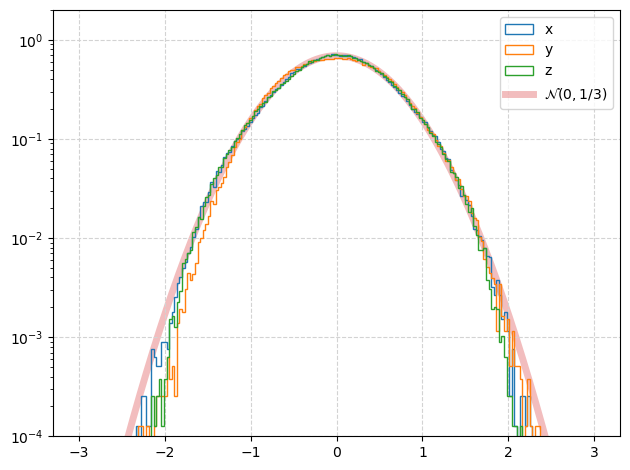

In [1160]:
import matplotlib.pyplot as plt
from scipy.stats import norm

vals = np.linspace(-3, 3, 1000)
plt.hist(B_field[..., 0].ravel(), bins=200, range=[-3, 3],
         histtype='step', density=True,
         label='x')
plt.hist(B_field[..., 1].ravel(), bins=200, range=[-3, 3],
         histtype='step', density=True,
         label='y')
plt.hist(B_field[..., 2].ravel(), bins=200, range=[-3, 3],
         histtype='step', density=True,
         label='z')

plt.plot(vals, norm(loc=0, scale=1/np.sqrt(3)).pdf(vals),
         linestyle='solid', linewidth=5, alpha=.3, zorder=0,
         label=r'$\mathcal{N}(0, 1/3)$')

plt.ylim(1e-4, 2)
plt.yscale('log')

plt.grid(linestyle='dashed', color='lightgray')

plt.legend()
plt.tight_layout()
plt.show()

### 1.5. Tests

#### A. Fourier space transversality check

In [1161]:
from scipy.fft import fftn, ifftn

In [1162]:
# check the transversality
div_k = np.sum(1j * k_grid * B_k_field, axis=-1)
test_value = np.abs(div_k).max()
print(f"Maximal value of divergence: {test_value:.4g}")

if test_value < 1e-10:
    print("TEST PASSED")
else:
    print("! ATTENTION ! TEST FAILURE...")

Maximal value of divergence: 1.169e-14
TEST PASSED


#### B. Full FFT divergence-free check

In [1204]:
B_k = fftn(B_field, axes=(0,1,2))
div_k = np.sum(1j * k_grid * B_k, axis=-1)

In [1205]:
div = ifftn(div_k).real
test_value = np.max(np.abs(div))

print(f"Maximal value of divergence: {test_value:.4g}")
if test_value < 1e-3:
    print("TEST PASSED")
else:
    print("! ATTENTION ! TEST FAILURE...")

Maximal value of divergence: 0.006686
! ATTENTION ! TEST FAILURE...


#### C. Power-spectrum slope check

In [1206]:
from scipy.stats import binned_statistic

In [1207]:
dk = np.abs(k_x[1] - k_x[0])
bins = np.arange(0, k_norm_grid.max() + dk, dk)

In [1208]:
# obtain spectral energy density of the magnetic field in Fourier space
Bk2 = np.var(B_k, axis=-1)  # sum of the squares of the Fourier transformed components
k = np.linalg.norm(k_grid**2, axis=-1)  # calculate the magnitude of the wavevector

k_flat = k.ravel()
Bk2_flat = Bk2.ravel()

In [1209]:
from scipy.stats import binned_statistic

power, edges, _ = binned_statistic(
    k_flat,
    Bk2_flat,
    statistic="sum",
    bins=bins,
)

k_centers = 0.5 * (edges[:-1] + edges[1:])

In [1210]:
import matplotlib.pyplot as plt

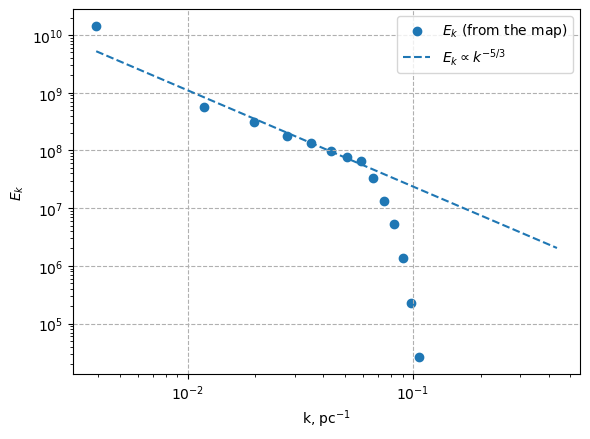

In [1211]:
plt.figure(figsize=(6, 4.5))
plt.scatter(k_centers, power, label=r'$E_k$ (from the map)')
plt.loglog(k_centers, power[5] * (k_centers / k_centers[5])**(-5/3), linestyle='dashed', label=r'$E_k\propto k^{-5/3}$')

# plt.xlim(k.min() + 5e-4, k.max() * 1.05)
plt.xlabel(r'k, $\mathrm{pc}^{-1}$')

# plt.ylim(1e10, 1e16)
plt.ylabel(r'$E_k$')

plt.legend(loc=1)

plt.grid(linestyle='dashed')

plt.tight_layout()
plt.show()

#### D. Isotropy check

In [1212]:
print(k_grid.shape)
print(k.shape)

(64, 64, 64, 3)
(64, 64, 64)


To check isotropy, we investigate distributions in $\mu = \cos\theta_z = k_z/k$ and $\nu = \cos\theta_x = k_x/k$.

However, if we simply bin the array in the angles, we will be dominated by large $k$ as $P(k)\propto k^{-11/3}$.

So, we first bin in $k$, normalize the distribution and then bin it in $\mu$ or $\nu$.

In [1213]:
mu, nu = np.zeros_like(k), np.zeros_like(k)

In [1214]:
# Flatten arrays
k_flat = k.ravel()
mu_flat = mu.ravel()
Bk2_flat = Bk2.ravel()

# Remove k = 0 mode
mask = k_flat > 0

In [1215]:
mask.shape

(262144,)

In [1216]:
# Remove k = 0 mode
mask = (k > 0.1) & (k < 5)
k_mask = k[mask]
mu_mask = k_grid[..., 0][mask] / k_mask
Bk2_mask = Bk2[mask]

# flatten the arrays
k_flat = k_mask.ravel()
mu_flat = mu_mask.ravel()
Bk2_flat = Bk2_mask.ravel()

In [1219]:
# ----- Shell-average spectrum -----
n_k_bins = 5
k_bins = np.geomspace(k_flat.min(), k_flat.max(), n_k_bins + 1)

shell_mean, _, shell_index = binned_statistic(
    k_flat,
    Bk2_flat,
    statistic="mean",
    bins=k_bins,
)

shell_mean

array([440.70480562, 456.819297  , 336.47020213, 411.66498193,
       535.41589671])

In [1225]:
# Normalize each Fourier mode by its shell average
Bk2_norm = Bk2_flat / shell_mean[shell_index - 1]

# ----- Angular anisotropy -----
n_mu_bins = 10
mu_bins = np.linspace(-1, 1, n_mu_bins)

anisotropy, mu_edges, _ = binned_statistic(
    mu_flat,
    Bk2_norm,
    statistic="mean",
    bins=mu_bins,
)

mu_centers = 0.5 * (mu_edges[:-1] + mu_edges[1:])

anisotropy

array([nan, nan, nan, nan, nan, nan, nan, nan, nan])

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


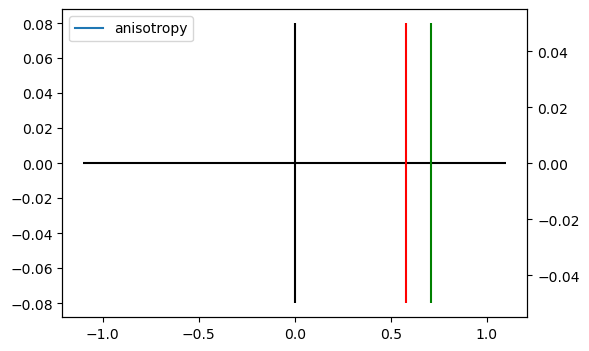

In [1226]:
plt.figure(figsize=(6, 4))

ax = plt.subplot(111)
ax.plot(mu_centers, 1 - anisotropy, label='anisotropy')

ax2 = ax.twinx()
ax2.hist(mu_flat, bins=mu_bins, histtype='step', color='orange', density=True, label=r'$\mu$ distribution')

ax.hlines([0], -1.1, 1.1, color='black')
ax.vlines([0, 1/np.sqrt(3), 1/np.sqrt(2)], -0.08, 0.08, colors=['black', 'r', 'g'])

ax.legend(loc=2)

plt.show()

**Verdict:** The distribution is isotropic

#### E. Zero mean

In [1227]:
np.mean(B_field)

np.complex128(-6.938893903907228e-18+1.976410210260034e-21j)

#### F. Correlation function

#### G. Parseval identity